# Base-Widener + Concentration-vs-Absorption SAE Edit Population Test (iter-8)

**CCRG auditability spine, iter-8 (M2‴ / M3‴ / M5‴).** This demo reproduces the *decision layer* of the iter-8 experiment from its precomputed per-candidate data.

### The question
iter-7 found that ablating **one** KG-named SAE *absorber* latent can beat a fair dense control at meaningful forget — but only for the concentrated spelling word `large`, while distributed country senses (`Georgia`/`Jordan`) could not forget at all. iter-8 widens the candidate vocabulary (spelling word-absorbers `L/O/T/I/D` + homograph entities: brands / given-names / months / cities) and asks three population-level questions:

- **M2‴ (base width):** how many candidates clear the fair-control bar at *meaningful forget*? → `BASE_REACHES_4_PLUS` vs `BASE_STAYS_THIN_RETARGET`.
- **M3‴ (predictor):** does a candidate's **continuous lexical-concentration** score predict its edit outcome better than its **binary absorption-regime** label? → `CONCENTRATION_PREDICTS` vs `ABSORPTION_PREDICTS` vs `TIE/UNDERPOWERED`.
- **M5‴ (set-cover inertness):** for how many candidates does the anchored precision-selected absorber **equal** the unconstrained max-precision latent? (high ⇒ the K-track set-cover step is inert).

### What this notebook runs
The heavy half of `method.py` — forward passes through **Gemma-2-2b + a Gemma-Scope L12/16k JumpReLU SAE** on a GPU — produces a `$0` concentration screen per candidate plus, for a handful of candidates, judged edit results. Those GPU outputs are **precomputed** and shipped as `mini_demo_data.json` (one row per screened candidate; the edited candidates additionally carry their judged edit fields).

This notebook loads that data and re-runs the **verbatim CPU analysis** from `method.py` — `_spearman_ci`, `_pointbiserial_ci`, `population_predictor`, the base-count verdict, and the set-cover inertness rate — reproducing the paper's M2‴/M3‴/M5‴ verdicts. No GPU, no model download, runs in seconds.

In [1]:
# --- Install dependencies (Colab-safe) ---
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy, scipy, matplotlib are pre-installed on Colab. On Colab we MUST NOT reinstall them
# (it corrupts the loaded C extensions); locally we install Colab's exact versions to match.
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'scipy==1.16.3', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- Imports (mirrors the analysis half of method.py) ---
import os, sys, json, math
from collections import Counter, defaultdict

import numpy as np
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

In [3]:
# --- Data loading helper: GitHub raw URL with local fallback (Colab-compatible) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7ee30c-catching-silent-feature-absorption-in-fr/main/round-8/experiment-2/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["_about"][:280], "...\n")
print("config:", {k: data["config"][k] for k in ('SEED', 'B_BOOT_full', 'FORGET_FLOOR')})
print("SAE   :", data["config"]["sae"])
print("model :", data["config"]["model"])
print("gating:", data["config"]["gating_check"]["pass"],
      "| cosine", data["config"]["gating_check"]["cosine"],
      "| L0", data["config"]["gating_check"]["L0"])
print("\ncandidates loaded:", len(data["candidates"]))

iter-8 Base-Widener + Concentration-vs-Absorption population test. Each row is one screened candidate token with its $0 concentration-screen fields; the 5 candidates that went through the GPU edit loop additionally carry the judged edit fields (delta_joint_*, concentrated_win, .. ...

config: {'SEED': 1234, 'B_BOOT_full': 10000, 'FORGET_FLOOR': 0.1}
SAE   : {'release': 'google/gemma-scope-2b-pt-res', 'sae_params': 'layer_12/width_16k/average_l0_82', 'width': 16384, 'd_model': 2304, 'hook': 'blocks.12.hook_resid_post'}
model : google/gemma-2-2b
gating: True | cosine 0.919 | L0 88.0

candidates loaded: 90


## Config

All tunable parameters live here. They are set to small demo values; the commented values restore the original full-run settings.

- `SEED` — RNG seed for the bootstrap CIs (the verbatim `method.py` value is `1234`).
- `B_CI` — number of bootstrap resamples for the Spearman / point-biserial confidence intervals. `method.py` uses `2000`; the analysis is tiny so this only affects CI smoothness, not the verdict.
- `FORGET_FLOOR` — the meaningful-forget sub-probe-drop floor (carried from the screen; reported only).
- `POSITIVE_CONTROLS` — the only iter-7-established absorption win (`large`), counted separately from fresh wins.
- `N_DISPLAY` / `N_BARS` — how many rows / bars to show in the result views.

In [5]:
# ---- tunable demo config (start small; comment shows the original full-run value) ----
SEED            = data["config"]["SEED"]      # 1234 (verbatim from method.py core.SEED)
B_CI            = 2000                         # bootstrap resamples for CIs (method.py full-run value; sub-second here)
FORGET_FLOOR    = data["config"]["FORGET_FLOOR"]
POSITIVE_CONTROLS = {"large"}                 # iter-7's single established KG_BEATS win
N_DISPLAY       = 20                           # rows to print in the screen table
N_BARS          = 30                           # candidates to show in the concentration bar chart

# global RNG used by the verbatim bootstrap helpers below (method.py: rng = np.random.default_rng(SEED))
rng = np.random.default_rng(SEED)

candidates = data["candidates"]               # one dict per screened candidate token
edited     = [c for c in candidates if c.get("edited")]   # the GPU-edited subset (carry judged fields)
print(f"{len(candidates)} screened candidates | {len(edited)} went through the edit loop:",
      [c["uid"] for c in edited])

90 screened candidates | 5 went through the edit loop: ['first_letter_spelling::the', 'first_letter_spelling::long', 'first_letter_spelling::large', 'taxonomic_country::Jordan', 'taxonomic_country::Georgia']


## 1. The `$0` concentration screen

Each candidate carries the per-token screen fields computed on the GPU (precomputed here). The **primary** `concentration_score` is the analytic forget-capture fraction — the share of the average target context's frozen sub-probe margin removed by ablating the single anchored absorber latent. High ⇒ the sub-context's detectable signal is **concentrated** in one latent (editable, like spelling `large`); low ⇒ **distributed** across many latents (country `Georgia`/`Jordan`).

`absorption_structured` is the binary regime label (recall-hole + anchor-disjoint firing) that M3‴ pits the continuous score against. We sort by concentration and print the head.

In [6]:
# Rank candidates by concentration (exactly as method.py ranks screen_rows before editing).
screen_rows = sorted(candidates, key=lambda r: r["concentration_score"], reverse=True)

hdr = f"{'token':>14} {'hierarchy':>22} {'conc':>6} {'prec':>5} {'foot':>7} {'absorb':>6} {'setcov_eq':>9} {'edited':>6}"
print(hdr); print('-' * len(hdr))
for r in screen_rows[:N_DISPLAY]:
    print(f"{r['token']:>14} {r['hierarchy']:>22} {r['concentration_score']:>6.3f} "
          f"{r['precision']:>5.2f} {r['footprint']:>7.4f} "
          f"{str(r['absorption_structured']):>6} {str(r['set_cover_eq_max_precision']):>9} "
          f"{'*' if r.get('edited') else '':>6}")
print(f"\n... {len(screen_rows) - N_DISPLAY} more candidates not shown.")

         token              hierarchy   conc  prec    foot absorb setcov_eq edited
----------------------------------------------------------------------------------
           the         first_letter_T  1.376  0.98  0.0384   True     False      *
          long         first_letter_L  1.227  0.99  0.0012   True      True      *
          this         first_letter_T  1.186  0.96  0.0044   True     False       
           one         first_letter_O  1.176  0.99  0.0019   True     False       
          Mark   homograph_given_name  1.075  1.00  0.0009  False      True       
         large         first_letter_L  1.066  0.98  0.0009   True      True      *
          Hope   homograph_given_name  1.041  1.00  0.0006  False      True       
          Bill   homograph_given_name  1.001  0.93  0.0017  False     False       
           law         first_letter_L  0.902  0.99  0.0009   True      True       
     different         first_letter_D  0.902  0.99  0.0005   True     False       
    

## 2. Verbatim bootstrap-CI helpers (copied from `method.py`)

These two functions are copied **unchanged** from `method.py` (only the bootstrap count `B` is wired to the `B_CI` config variable). `_spearman_ci` gives the rank correlation between continuous concentration and the edit-magnitude outcome; `_pointbiserial_ci` correlates a binary regime label with a continuous/binary outcome. Both return a percentile bootstrap CI and an `excl_0` flag.

In [7]:
def _spearman_ci(x, y, B=2000):
    x = np.asarray(x, float); y = np.asarray(y, float)
    n = len(x)
    if n < 4:
        return {"rho": None, "ci_lo": None, "ci_hi": None, "n": int(n), "excl_0": False}
    rho = float(spearmanr(x, y).correlation)
    bs = []
    for _ in range(B):
        idx = rng.integers(0, n, n)
        if len(np.unique(x[idx])) < 2 or len(np.unique(y[idx])) < 2:
            continue
        bs.append(float(spearmanr(x[idx], y[idx]).correlation))
    if not bs:
        return {"rho": rho, "ci_lo": None, "ci_hi": None, "n": int(n), "excl_0": False}
    lo, hi = np.percentile(bs, [2.5, 97.5])
    return {"rho": round(rho, 4), "ci_lo": round(float(lo), 4), "ci_hi": round(float(hi), 4),
            "n": int(n), "excl_0": bool(lo > 0 or hi < 0)}


def _pointbiserial_ci(binary, cont, B=2000):
    """Correlation between a binary var and a continuous var (point-biserial = Pearson)."""
    b = np.asarray(binary, float); c = np.asarray(cont, float)
    n = len(b)
    if n < 4 or len(np.unique(b)) < 2:
        return {"r": None, "ci_lo": None, "ci_hi": None, "n": int(n), "excl_0": False}
    def _r(bb, cc):
        if len(np.unique(bb)) < 2 or np.std(cc) < 1e-9:
            return 0.0
        return float(np.corrcoef(bb, cc)[0, 1])
    r = _r(b, c)
    bs = []
    for _ in range(B):
        idx = rng.integers(0, n, n)
        bs.append(_r(b[idx], c[idx]))
    lo, hi = np.percentile(bs, [2.5, 97.5])
    return {"r": round(r, 4), "ci_lo": round(float(lo), 4), "ci_hi": round(float(hi), 4),
            "n": int(n), "excl_0": bool(lo > 0 or hi < 0)}

## 3. M3‴ — population predictor (verbatim)

`population_predictor` is copied **unchanged** from `method.py` (the two internal CI calls pass `B=B_CI`). It pits the continuous **concentration** score against the binary **absorption-structured** label as predictors of the edit outcome, over the edited candidates that carry a `Δ_joint(KG vs fair)`. The verdict is `CONCENTRATION_PREDICTS` only when concentration's CI excludes 0 and absorption's does not.

In [8]:
def population_predictor(edited):
    """C=concentration (continuous), S=absorption_structured (binary). Outcomes Ymag=delta_joint(KG vs fair)
    diff (continuous), Ywin=concentrated_win (binary). Decide CONCENTRATION_PREDICTS vs ABSORPTION_PREDICTS."""
    rows = [e for e in edited if e.get("delta_joint_vs_fair_primary") is not None]
    if len(rows) < 4:
        return {"predictor_verdict": "TIE/UNDERPOWERED", "n": len(rows),
                "note": "fewer than 4 edited candidates with a Delta_joint; cannot identify the contrast"}
    C = [e["concentration_score"] for e in rows]
    S = [1.0 if e["absorption_structured"] else 0.0 for e in rows]
    Ymag = [e["delta_joint_vs_fair_primary"]["diff"] for e in rows]
    Ywin = [1.0 if e.get("concentrated_win") else 0.0 for e in rows]
    res = {
        "n": len(rows),
        "spearman_conc_mag": _spearman_ci(C, Ymag, B=B_CI),
        "pb_conc_win": _pointbiserial_ci(Ywin, C, B=B_CI),
        "pb_absorp_mag": _pointbiserial_ci(S, Ymag, B=B_CI),
        "pb_absorp_win": _pointbiserial_ci(S, Ywin, B=B_CI),
    }
    conc_sig = res["spearman_conc_mag"]["excl_0"] or res["pb_conc_win"]["excl_0"]
    absorp_sig = res["pb_absorp_mag"]["excl_0"] or res["pb_absorp_win"]["excl_0"]
    if conc_sig and not absorp_sig:
        res["predictor_verdict"] = "CONCENTRATION_PREDICTS"
    elif absorp_sig and not conc_sig:
        res["predictor_verdict"] = "ABSORPTION_PREDICTS"
    else:
        res["predictor_verdict"] = "TIE/UNDERPOWERED"
    return res


pop = population_predictor(edited)
print("M3‴ population predictor (recomputed on the demo data):\n")
print(json.dumps(pop, indent=1))

M3‴ population predictor (recomputed on the demo data):

{
 "n": 5,
 "spearman_conc_mag": {
  "rho": 0.6,
  "ci_lo": -1.0,
  "ci_hi": 1.0,
  "n": 5,
  "excl_0": false
 },
 "pb_conc_win": {
  "r": null,
  "ci_lo": null,
  "ci_hi": null,
  "n": 5,
  "excl_0": false
 },
 "pb_absorp_mag": {
  "r": null,
  "ci_lo": null,
  "ci_hi": null,
  "n": 5,
  "excl_0": false
 },
 "pb_absorp_win": {
  "r": null,
  "ci_lo": null,
  "ci_hi": null,
  "n": 5,
  "excl_0": false
 },
 "predictor_verdict": "TIE/UNDERPOWERED"
}


## 4. M2‴ — base-count verdict (verbatim)

Counts the **independent concentrated wins** across the edited candidates (a win = `meaningful_forget` AND KG beats the fair control on both judges, i.e. `concentrated_win == True`). `large` is the one pre-established positive control, counted separately from fresh wins. Four or more distinct wins → `BASE_REACHES_4_PLUS`, else `BASE_STAYS_THIN_RETARGET`.

In [9]:
# ---- verdict (M2‴ base count) ---- copied from method.main()
edited_list = edited
new_wins = sorted({e["token"] for e in edited_list
                   if e.get("concentrated_win") and e["token"] not in POSITIVE_CONTROLS})
known_wins = sorted({e["token"] for e in edited_list
                     if e.get("concentrated_win") and e["token"] in POSITIVE_CONTROLS})
total_wins = len(set(known_wins) | set(new_wins))
verdict = "BASE_REACHES_4_PLUS" if total_wins >= 4 else "BASE_STAYS_THIN_RETARGET"

# positive-control reproduction check (look up by token)
pc_repro = {}
for pc in POSITIVE_CONTROLS:
    hit = next((e for e in edited_list if e.get("token") == pc), None)
    if hit is not None:
        pc_repro[pc] = bool(hit.get("kg_beats_fair"))

base_count = {"known_wins": known_wins, "new_wins": new_wins,
              "total_independent_concentrated_wins": total_wins, "verdict": verdict,
              "positive_control_reproduces": pc_repro}
print("M2‴ base count (recomputed on the demo data):\n")
print(json.dumps(base_count, indent=1))

print("\nper-edited-candidate outcome:")
for e in sorted(edited_list, key=lambda r: -r["concentration_score"]):
    dj = e.get("delta_joint_vs_fair_primary") or {}
    print(f"  {e['token']:>8} | conc={e['concentration_score']:.3f} | status={e['status']:>18} | "
          f"meaningful_forget={str(e.get('meaningful_forget')):>5} | kg_beats_fair={str(e.get('kg_beats_fair')):>5} | "
          f"Δjoint_vs_fair={dj.get('diff')}")

M2‴ base count (recomputed on the demo data):

{
 "known_wins": [],
 "new_wins": [],
 "total_independent_concentrated_wins": 0,
 "verdict": "BASE_STAYS_THIN_RETARGET",
 "positive_control_reproduces": {
  "large": false
 }
}

per-edited-candidate outcome:
       the | conc=1.376 | status= meaningful_no_win | meaningful_forget= True | kg_beats_fair=False | Δjoint_vs_fair=-0.05
      long | conc=1.227 | status= meaningful_no_win | meaningful_forget= True | kg_beats_fair=False | Δjoint_vs_fair=0.0
     large | conc=1.066 | status= meaningful_no_win | meaningful_forget= True | kg_beats_fair=False | Δjoint_vs_fair=0.0667
    Jordan | conc=0.136 | status=no_meaningful_forget | meaningful_forget=False | kg_beats_fair=False | Δjoint_vs_fair=-0.1
   Georgia | conc=0.059 | status=no_meaningful_forget | meaningful_forget=False | kg_beats_fair=False | Δjoint_vs_fair=-0.15


## 5. M5‴ — set-cover inertness rate (verbatim)

For every screened candidate with an anchored absorber, does that absorber **equal** the unconstrained max-precision latent? The fraction that do is the set-cover inertness rate: high ⇒ the K-track set-cover step adds nothing beyond picking the single most precise latent (an honest negative). Computed here over the demo subset; the full-run value over all 111 candidates is shown for comparison.

In [10]:
# ---- set-cover inertness (M5‴) over screened candidates with an absorber ---- copied from method.main()
with_abs = [r for r in screen_rows if r["absorber"] is not None]
set_cover_inert = (float(np.mean([1.0 if r["set_cover_eq_max_precision"] else 0.0 for r in with_abs]))
                   if with_abs else None)

print(f"M5‴ set-cover inertness (demo subset): {set_cover_inert:.4f}  "
      f"({sum(r['set_cover_eq_max_precision'] for r in with_abs)}/{len(with_abs)} candidates)")
print(f"     reference full-run (all {data['reference_full_run']['set_cover_n_with_absorber']} candidates): "
      f"{data['reference_full_run']['set_cover_inertness_rate']:.4f}")

M5‴ set-cover inertness (demo subset): 0.4111  (37/90 candidates)
     reference full-run (all 111 candidates): 0.3694


## 6. Results — visualization & verdict summary

**Left:** the concentration screen — candidates ranked by concentration, coloured by absorption regime, with the GPU-edited candidates marked. Note the editable spelling absorbers sit high while the distributed country senses sit low. **Right:** the M3‴ population scatter — concentration vs the judged Δ_joint(KG vs fair) for the edited candidates.

Below the plots we print the three verdicts recomputed here side-by-side with the original full-run values.

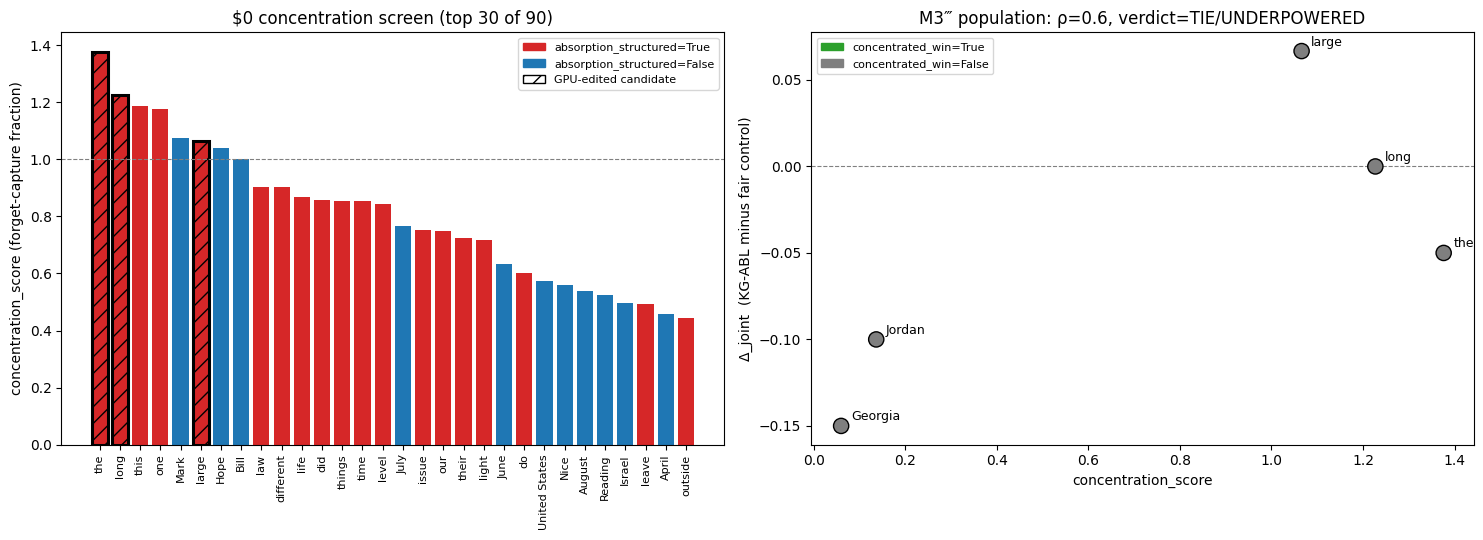

verdict                   this demo                 original full run
------------------------------------------------------------------------
M2‴ base count            BASE_STAYS_THIN_RETARGET  BASE_STAYS_THIN_RETARGET
M2‴ total wins            0                         0
M3‴ predictor             TIE/UNDERPOWERED          TIE/UNDERPOWERED
M3‴ spearman rho          0.6                       0.6
M5‴ set-cover inertness   0.4111                    0.3694

Honest negatives carried from the full run:
 • BASE_STAYS_THIN: only 0 independent concentrated win(s) ([]) cleared the fair bar -> paper retargets to localization+editing of homograph-polysemy/spelling absorption.
 • PREDICTOR: concentration does NOT out-predict absorption-structure (verdict=TIE/UNDERPOWERED, n=5) -> reframe unsupported / underpowered; reported as-is with CIs.
 • NO_MEANINGFUL_FORGET candidates (single-latent ablation can't forget at full strength): ['Georgia', 'Jordan'] -- carries the iter-7 Georgia/Jordan distribute

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

# --- left: concentration bar chart, coloured by absorption regime, edited marked ---
top = screen_rows[:N_BARS]
xs = np.arange(len(top))
cols = ['#d62728' if r['absorption_structured'] else '#1f77b4' for r in top]
bars = ax1.bar(xs, [r['concentration_score'] for r in top], color=cols)
for i, r in enumerate(top):
    if r.get('edited'):
        bars[i].set_edgecolor('black'); bars[i].set_linewidth(2.2); bars[i].set_hatch('//')
ax1.axhline(1.0, color='grey', ls='--', lw=0.8)
ax1.set_xticks(xs)
ax1.set_xticklabels([r['token'] for r in top], rotation=90, fontsize=8)
ax1.set_ylabel('concentration_score (forget-capture fraction)')
ax1.set_title(f'\\$0 concentration screen (top {len(top)} of {len(screen_rows)})')
from matplotlib.patches import Patch
ax1.legend(handles=[Patch(color='#d62728', label='absorption_structured=True'),
                    Patch(color='#1f77b4', label='absorption_structured=False'),
                    Patch(facecolor='white', edgecolor='black', hatch='//', label='GPU-edited candidate')],
           fontsize=8, loc='upper right')

# --- right: M3‴ population scatter (concentration vs judged Δ_joint) ---
C = [e['concentration_score'] for e in edited_list]
Y = [e['delta_joint_vs_fair_primary']['diff'] for e in edited_list]
wins = [e.get('concentrated_win') for e in edited_list]
ax2.scatter(C, Y, s=120, c=['#2ca02c' if w else '#7f7f7f' for w in wins], zorder=3, edgecolors='black')
for e in edited_list:
    ax2.annotate(e['token'], (e['concentration_score'], e['delta_joint_vs_fair_primary']['diff']),
                 textcoords='offset points', xytext=(7, 4), fontsize=9)
ax2.axhline(0.0, color='grey', ls='--', lw=0.8)
ax2.set_xlabel('concentration_score')
ax2.set_ylabel('Δ_joint  (KG-ABL minus fair control)')
ax2.set_title(f"M3‴ population: ρ={pop['spearman_conc_mag']['rho']}, "
              f"verdict={pop['predictor_verdict']}")
ax2.legend(handles=[Patch(color='#2ca02c', label='concentrated_win=True'),
                    Patch(color='#7f7f7f', label='concentrated_win=False')], fontsize=8)
plt.tight_layout(); plt.show()

# --- verdict summary vs the original full run ---
ref = data['reference_full_run']
print('=' * 72)
print(f"{'verdict':<26}{'this demo':<26}{'original full run'}")
print('-' * 72)
print(f"{'M2‴ base count':<26}{verdict:<26}{ref['base_count']['verdict']}")
print(f"{'M2‴ total wins':<26}{str(total_wins):<26}{ref['base_count']['total_independent_concentrated_wins']}")
print(f"{'M3‴ predictor':<26}{pop['predictor_verdict']:<26}{ref['population_predictor']['predictor_verdict']}")
print(f"{'M3‴ spearman rho':<26}{str(pop['spearman_conc_mag']['rho']):<26}{ref['population_predictor']['spearman_conc_mag']['rho']}")
print(f"{'M5‴ set-cover inertness':<26}{round(set_cover_inert,4):<26}{ref['set_cover_inertness_rate']}")
print('=' * 72)
print('\nHonest negatives carried from the full run:')
for h in ref['honest_negatives']:
    print(' •', h)